In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Outros algoritmos

### Base de dados cobertura vegetal

Neste exercício você vai usar a base de dados de cobertura vegetal, explorada nos exercícios da **Parte 1 - Classificação**.

Comece carregando os dados do arquivo `cov_types.csv` armazenado na pasta do Drive.

In [2]:
base = pd.read_csv("cov_types.csv")
base

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
0,2767.0,66.0,17.0,210.0,18.0,1190.0,234.0,204.0,96.0,2251.0,2,30,Lodgepole Pine
1,2724.0,160.0,19.0,60.0,4.0,1350.0,236.0,240.0,127.0,2514.0,2,16,Lodgepole Pine
2,2360.0,65.0,7.0,127.0,21.0,1377.0,227.0,226.0,134.0,339.0,3,5,Ponderosa Pine
3,2995.0,45.0,4.0,285.0,30.0,5125.0,221.0,231.0,146.0,5706.0,0,11,Lodgepole Pine
4,2400.0,106.0,27.0,150.0,63.0,342.0,253.0,196.0,51.0,811.0,2,3,Ponderosa Pine
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2917.0,90.0,9.0,247.0,25.0,4095.0,235.0,225.0,121.0,3901.0,0,28,Lodgepole Pine
9996,3015.0,38.0,8.0,361.0,74.0,4846.0,220.0,223.0,138.0,1611.0,0,28,Lodgepole Pine
9997,3052.0,79.0,19.0,90.0,11.0,1003.0,241.0,203.0,85.0,1490.0,2,22,Spruce/Fir
9998,2958.0,58.0,6.0,319.0,19.0,2468.0,225.0,227.0,137.0,2280.0,0,28,Lodgepole Pine


Remova as colunas categóricas, `Wilderness_Area` e `Soil_Type`.

In [5]:
base = base.drop(["Wilderness_Area", "Soil_Type"], axis = 1)

Separe a coluna com a variável alvo `Cover_Type` em uma variável `y`.

In [6]:
y = base["Cover_Type"]

Separe as demais colunas em uma variável `X`, no formato de NumPy array.

In [7]:
X = base.iloc[:, :-1].values

Escalone os valores de `X` utilizando `StandardScaler`.

In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

Agora gere um dendograma de `X`, utilizando `method=ward`. Exiba o dendrograma gerado.

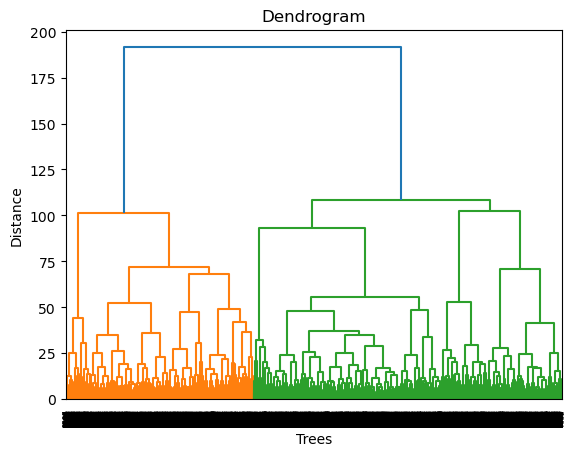

In [9]:
dendrogram = dendrogram(linkage(X, method = "ward"))
plt.title("Dendrogram")
plt.xlabel("Trees")
plt.ylabel("Distance")
plt.show()

Agrupe os dados com `AgglomerativeClustering`, utilizando `n_clusters=7`,  `metric="euclidean"` e `linkage="ward"`. Recupere os rótulos com `fit_predict`.

In [10]:
agg =AgglomerativeClustering(n_clusters = 7, linkage = "ward")
labels = agg.fit_predict(X)

Vamos visualizar os dados junto com os rótulos gerados. Comece transformando `X` com a técnica de PCA, utilizando 2 componentes.

In [11]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

Plote o PCA, utilizando como argumento para cor os rótulos gerados pelo algoritmo, no formato de string.

In [12]:
fig = px.scatter(x = X_pca[:, 0], y = X_pca[:, 1], color = labels.astype(str), title = "Agrupamento com PCA")
fig.show()

Compare os rótulos gerados com as classes originais.

In [13]:
pd.crosstab(labels, y)

Cover_Type,Aspen,Cottonwood/Willow,Douglas-fir,Krummholz,Lodgepole Pine,Ponderosa Pine,Spruce/Fir
row_0,,,,,,,
0,8,0,0,25,820,0,655
1,10,1,13,95,866,32,697
2,78,30,111,108,1740,222,1108
3,18,0,2,66,384,18,432
4,0,3,92,9,136,152,102
5,19,13,26,24,133,72,90
6,30,8,34,35,768,85,630


Novamente, se vê pouca correlação entre os rótulos.

Agora treine um algoritmo DBSCAN, com `eps=0.95` e `min_samples=2`.

In [14]:
dbscan = DBSCAN(eps = 0.95, min_samples = 2)
dbscan.fit(X)

DBSCAN(eps=0.95, min_samples=2)

Recupere os rótulos e exiba o gráfico de PCA.

In [15]:
labels = dbscan.labels_

In [16]:
fig = px.scatter(x = X_pca[:, 0], y = X_pca[:, 1], color = labels.astype(str), title = "Agrupamento com DBSCAN")
fig.show()

Veja que este algoritmo não utiliza o número de grupos como argumento, então ele pode gerar tantos grupos quanto julgue necessário. Além disso, ele cria um grupo chamado `-1` com os dados que ele considera que não fazem parte de nenhum grupo.